# Complex Experiment: Full Backend Capabilities Test

This notebook tests the complete FIREQ backend workflow with:
- Multi-shot hardware repetitions
- Readout pulse configuration
- Drive carrier setup
- Envelope upload
- Timing validation
- Complete experiment execution
- Statistical analysis across shots

**Target**: Validate the backend can run production-like quantum experiments.

## 1. Setup & Initialization

In [33]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from pynq import PL

sys.path.insert(0, os.path.join(os.getcwd(), 'fireq_utils'))

from backend import FireqHardwareBackend
from backend import (
    DMATimeoutError, 
    DMAError,
    TimingError, 
    ConfigurationError,
    DriverError,
    FireqHardwareError
)
from FIREQ_LL_API.overlay_driver import FIREQ_SoC

BITSTREAM_PATH = "/home/xilinx/jupyter_notebooks/api_test_giorgio/fireq_ol/NEW_FIREQ.bit"
if not os.path.exists(BITSTREAM_PATH):
    raise FileNotFoundError(f"Bitstream not found!")

print("Imports OK")

Imports OK


In [34]:
PL.reset()
print("Loading FIREQ overlay...")
overlay = FIREQ_SoC(BITSTREAM_PATH)

print("Initializing backend with debug=True...")
backend = FireqHardwareBackend(overlay, debug=True)

print(f"\n=== SYSTEM READY ===")
print(f"DAC Sample Rate: {backend.DAC_SR/1e9:.3f} GSPS")
print(f"ADC Sample Rate: {backend.ADC_SR/1e9:.3f} GSPS")
print(f"Generators: {len(backend.hw.gens)}")
print(f"Acquisitions: {len(backend.hw.acqs)}")
print(f"Logical Map: {list(backend.logical_map.keys())}")

Loading FIREQ overlay...


[Backend] INFO: Initializing Backend...
[Backend] DEBUG: Step 1: Discovering hardware via HardwareInventory...
[Backend] DEBUG: HardwareInventory: Scanning overlay for IPs...
[Backend] DEBUG:   Phase 1: Discovering custom IPs...
[Backend] DEBUG:     [OK] Found 1 Signal Generator(s)
[Backend] DEBUG:     [OK] Found 2 Acquisition IP(s)
[Backend] DEBUG:     [OK] Found Trigger Generator
[Backend] DEBUG:   Phase 2: Discovering infrastructure IPs...
[Backend] DEBUG:     [OK] Found AXI DMA Controller
[Backend] DEBUG:     [OK] Found RF-DC Controller
[Backend] DEBUG:     [OK] Found AXI Switch
[Backend] DEBUG: Validating RF clocks and discovering sample rates...
[Backend] DEBUG:   Scanning DAC tiles...


Initializing backend with debug=True...


[Backend] DEBUG:     [OK] DAC Tile 0: 9.585 GSPS (Lock: 2)
[Backend] DEBUG:     [SKIP] DAC Tile 1: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:     [OK] DAC Tile 2: 9.585 GSPS (Lock: 2)
[Backend] DEBUG:     [SKIP] DAC Tile 3: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:   [OK] DAC sample rate: 9.585 GSPS
[Backend] DEBUG:   Scanning ADC tiles...
[Backend] DEBUG:     [OK] ADC Tile 0: 4.792 GSPS (Lock: 2)
[Backend] DEBUG:     [SKIP] ADC Tile 1: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:     [SKIP] ADC Tile 2: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:     [SKIP] ADC Tile 3: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:   [OK] ADC sample rate: 4.792 GSPS
[Backend] INFO: Clocks Validated. DAC: 9.585 GSPS, ADC: 4.792 GSPS
[Backend] DEBUG: Hardware specs populated: DAC 9.585G, ADC 4.792G
[Backend] DEBUG: Step 2: Creating GeneratorAdapters...
[Backend] DEBUG: Step 3: Creating AcquisitionAdapters...
[Backend


=== SYSTEM READY ===
DAC Sample Rate: 9.585 GSPS
ADC Sample Rate: 4.792 GSPS
Generators: 1
Acquisitions: 2
Logical Map: ['Readout_Line', 'Qubit_0']


## 2. Initial Health Check

In [35]:
def print_health(health):
    """Pretty print health check results."""
    print("\n=== HARDWARE HEALTH ===")
    print(f"  DMA:     {health['dma']}")
    print(f"  Clocks:  {health['clocks']}")
    print(f"  Trigger: {health['trigger']}")
    for g in health['generators']:
        print(f"  Gen[{g['index']}]: {g['status']}")
    for a in health['acquisitions']:
        print(f"  Acq[{a['index']}]: {a['status']}")
    
    # Check for issues
    issues = []
    if health['dma'] != 'idle':
        issues.append(f"DMA not idle: {health['dma']}")
    if health['clocks'] != 'ok':
        issues.append(f"Clocks issue: {health['clocks']}")
    
    if issues:
        print("\nWARNINGS:")
        for issue in issues:
            print(f"    - {issue}")
    else:
        print("\n All systems nominal")
    
    return len(issues) == 0

health = backend.check_hardware_health()
is_healthy = print_health(health)


=== HARDWARE HEALTH ===
  DMA:     busy
  Clocks:  ok
  Trigger: ready
  Gen[0]: ok
  Acq[0]: ok
  Acq[1]: ok

WARNINGS:
    - DMA not idle: busy


## 3. Experiment Configuration

Define parameters for a realistic quantum experiment.

In [36]:
# ============================================
# EXPERIMENT PARAMETERS
# ============================================

# Timing (in clock cycles @ ~600 MHz)
EXPERIMENT_DURATION = 5000   # Total shot duration
READOUT_DELAY = 100          # Delay before readout trigger
TIME_OF_FLIGHT = 80          # ADC delay compensation

# Readout configuration
READOUT_FREQ_MHZ = 200.0     # Readout modulation frequency
READOUT_PHASE = 0.0          # Initial phase
READOUT_AMP = 0.5            # Amplitude [0, 1]
READOUT_DURATION_SAMPLES = 1024  # Pulse length

# Acquisition
ACQ_SAMPLES = 500            # Samples per shot
ACQ_MODE = 'decimated'       # 'raw', 'decimated', or 'accumulated'
ACQ_TIMEOUT = 3              # Seconds

# Multi-shot
NUM_SHOTS = 10               # Hardware repetitions

print("=== EXPERIMENT CONFIGURATION ===")
print(f"Duration:     {EXPERIMENT_DURATION} cycles")
print(f"Readout:      {READOUT_FREQ_MHZ} MHz, amp={READOUT_AMP}")
print(f"Acquisition:  {ACQ_SAMPLES} samples ({ACQ_MODE})")
print(f"Shots:        {NUM_SHOTS}")

# Calculate expected timing
clock_freq = backend.DAC_SR / 16  # Fabric clock ~600 MHz
shot_time_us = EXPERIMENT_DURATION / clock_freq * 1e6
total_time_us = shot_time_us * NUM_SHOTS

print(f"\nExpected timing:")
print(f"  Fabric clock: ~{clock_freq/1e6:.1f} MHz")
print(f"  Shot duration: ~{shot_time_us:.1f} μs")
print(f"  Total experiment: ~{total_time_us:.1f} μs")

=== EXPERIMENT CONFIGURATION ===
Duration:     5000 cycles
Readout:      200.0 MHz, amp=0.5
Acquisition:  500 samples (decimated)
Shots:        10

Expected timing:
  Fabric clock: ~599.0 MHz
  Shot duration: ~8.3 μs
  Total experiment: ~83.5 μs


## 4. Timing Validation

Pre-validate parameters before running.

In [37]:
print(">>> PRE-FLIGHT TIMING VALIDATION")

readout_cfg = {
    'target_label': 'Readout_Line',
    'num_samples': ACQ_SAMPLES,
    'freq': READOUT_FREQ_MHZ,
    'mode': ACQ_MODE,
    'trigger_delay': READOUT_DELAY,
    'time_of_flight': TIME_OF_FLIGHT,
    'timeout': ACQ_TIMEOUT
}

try:
    # Use the timing validator directly
    backend._timing.validate_experiment(
        duration_cycles=EXPERIMENT_DURATION,
        shots=NUM_SHOTS,
        readout_cfg=readout_cfg
    )
    print(" Timing validation PASSED")
    
    # Show estimated acquisition time
    acq_time_us = backend._timing.estimate_acquisition_time_us(ACQ_SAMPLES, ACQ_MODE)
    print(f"  Estimated acquisition time: {acq_time_us:.2f} μs")
    
except TimingError as e:
    print(f"✗ Timing validation FAILED:")
    print(f"  {e}")
    raise

[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000


>>> PRE-FLIGHT TIMING VALIDATION
 Timing validation PASSED
  Estimated acquisition time: 0.83 μs


## 5. Configure Readout Pulse

In [38]:
print(">>> CONFIGURING READOUT PULSE")

try:
    backend.configure_readout_pulse(
        freq=READOUT_FREQ_MHZ,
        phase=READOUT_PHASE,
        duration_samples=READOUT_DURATION_SAMPLES,
        amp=READOUT_AMP,
        shape='rectangular',
        target_label='Readout_Line'
    )
    print(f" Readout pulse configured:")
    print(f"    Frequency: {READOUT_FREQ_MHZ} MHz")
    print(f"    Duration: {READOUT_DURATION_SAMPLES} samples")
    print(f"    Amplitude: {READOUT_AMP}")
    
except ConfigurationError as e:
    print(f"✗ Configuration failed: {e}")
    raise
except DriverError as e:
    print(f"✗ Driver error: {e}")
    raise

[Backend] DEBUG: Readout: 200.0MHz, 1024smp


>>> CONFIGURING READOUT PULSE
 Readout pulse configured:
    Frequency: 200.0 MHz
    Duration: 1024 samples
    Amplitude: 0.5


## 6. Single Shot Test

Verify single-shot execution before multi-shot.

In [39]:
print(">>> SINGLE SHOT TEST")

t_start = time.time()
try:
    data_single = backend.start_experiment(
        duration_cycles=EXPERIMENT_DURATION,
        shots=1,
        readout_cfg=readout_cfg,
        skip_validation=False
    )
    t_elapsed = time.time() - t_start
    
    print(f" Single shot completed in {t_elapsed*1000:.1f} ms")
    print(f"  Shape: {data_single.shape}")
    print(f"  Dtype: {data_single.dtype}")
    print(f"  Mag mean: {np.abs(data_single).mean():.2f}")
    print(f"  Mag std: {np.abs(data_single).std():.2f}")
    
except FireqHardwareError as e:
    print(f"✗ Experiment failed: {type(e).__name__}: {e}")
    raise

[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000


>>> SINGLE SHOT TEST


[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=1
[Backend] INFO: Acquired: (500,) samples


 Single shot completed in 39.7 ms
  Shape: (500,)
  Dtype: complex128
  Mag mean: 421.62
  Mag std: 1119.17


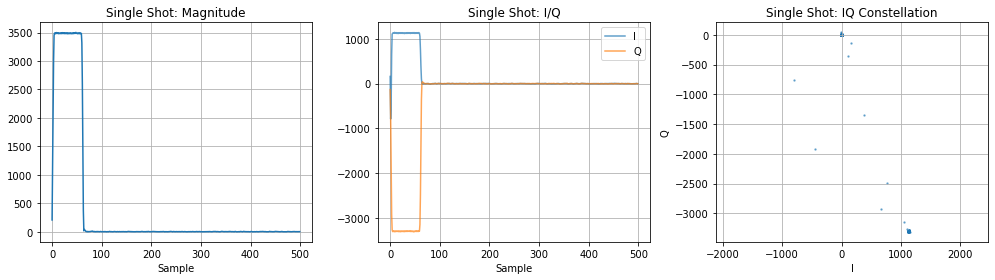

In [40]:
# Quick visualization of single shot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(np.abs(data_single))
axes[0].set_title('Single Shot: Magnitude')
axes[0].set_xlabel('Sample')
axes[0].grid(True)

axes[1].plot(data_single.real, label='I', alpha=0.7)
axes[1].plot(data_single.imag, label='Q', alpha=0.7)
axes[1].set_title('Single Shot: I/Q')
axes[1].set_xlabel('Sample')
axes[1].legend()
axes[1].grid(True)

axes[2].scatter(data_single.real, data_single.imag, s=2, alpha=0.5)
axes[2].set_title('Single Shot: IQ Constellation')
axes[2].set_xlabel('I')
axes[2].set_ylabel('Q')
axes[2].axis('equal')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 7. Multi-Shot Experiment

Execute multiple shots with hardware repetitions.

In [41]:
print(f">>> MULTI-SHOT EXPERIMENT ({NUM_SHOTS} shots)")

# Note: For hardware multi-shot, the backend returns concatenated data
# We need to reshape it to separate shots

t_start = time.time()
try:
    data_multi = backend.start_experiment(
        duration_cycles=EXPERIMENT_DURATION,
        shots=NUM_SHOTS,
        readout_cfg=readout_cfg,
        skip_validation=False
    )
    t_elapsed = time.time() - t_start
    
    print(f" Multi-shot completed in {t_elapsed*1000:.1f} ms")
    print(f"  Total samples: {len(data_multi)}")
    print(f"  Expected per shot: {ACQ_SAMPLES}")
    print(f"  Expected total: {ACQ_SAMPLES * NUM_SHOTS}")
    
    # Calculate throughput
    samples_per_sec = len(data_multi) / t_elapsed
    shots_per_sec = NUM_SHOTS / t_elapsed
    print(f"\nThroughput:")
    print(f"  {samples_per_sec/1e6:.2f} MSamples/sec")
    print(f"  {shots_per_sec:.1f} shots/sec")
    
except FireqHardwareError as e:
    print(f"✗ Multi-shot failed: {type(e).__name__}: {e}")
    raise

[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=10
[Backend] INFO: Acquired: (5000,) samples


>>> MULTI-SHOT EXPERIMENT (10 shots)
 Multi-shot completed in 40.1 ms
  Total samples: 5000
  Expected per shot: 500
  Expected total: 5000

Throughput:
  0.12 MSamples/sec
  249.7 shots/sec


In [42]:
# Reshape data to separate shots
expected_total = ACQ_SAMPLES * NUM_SHOTS

if len(data_multi) == expected_total:
    data_shots = data_multi.reshape(NUM_SHOTS, ACQ_SAMPLES)
    print(f" Data reshaped to ({NUM_SHOTS}, {ACQ_SAMPLES})")
else:
    print(f"Unexpected data length: {len(data_multi)} (expected {expected_total})")
    # Try to use what we have
    n_complete_shots = len(data_multi) // ACQ_SAMPLES
    if n_complete_shots > 0:
        data_shots = data_multi[:n_complete_shots * ACQ_SAMPLES].reshape(n_complete_shots, ACQ_SAMPLES)
        print(f"  Using {n_complete_shots} complete shots")
    else:
        data_shots = data_multi.reshape(1, -1)
        print(f"  Using as single shot with {data_shots.shape[1]} samples")

 Data reshaped to (10, 500)


## 8. Statistical Analysis

In [43]:
print(">>> SHOT-BY-SHOT ANALYSIS")

n_shots = data_shots.shape[0]

# Compute per-shot statistics
shot_stats = []
for i in range(n_shots):
    shot_data = data_shots[i]
    mag = np.abs(shot_data)
    shot_stats.append({
        'shot': i,
        'mag_mean': mag.mean(),
        'mag_std': mag.std(),
        'i_mean': shot_data.real.mean(),
        'q_mean': shot_data.imag.mean(),
        'integrated_i': shot_data.real.sum(),
        'integrated_q': shot_data.imag.sum()
    })

# Print table
print(f"\n{'Shot':<6} {'Mag Mean':<12} {'Mag Std':<12} {'I Mean':<12} {'Q Mean':<12}")
print("-" * 56)
for s in shot_stats:
    print(f"{s['shot']:<6} {s['mag_mean']:<12.2f} {s['mag_std']:<12.2f} "
          f"{s['i_mean']:<12.2f} {s['q_mean']:<12.2f}")

# Cross-shot statistics
mag_means = [s['mag_mean'] for s in shot_stats]
print(f"\n=== CROSS-SHOT STATISTICS ===")
print(f"  Mean of means: {np.mean(mag_means):.2f}")
print(f"  Std of means:  {np.std(mag_means):.2f}")
print(f"  CV (coefficient of variation): {np.std(mag_means)/np.mean(mag_means)*100:.2f}%")

>>> SHOT-BY-SHOT ANALYSIS

Shot   Mag Mean     Mag Std      I Mean       Q Mean      
--------------------------------------------------------
0      431.01       1130.02      121.27       -399.78     
1      437.09       1143.49      139.23       -410.86     
2      436.88       1143.25      138.64       -410.67     
3      436.81       1143.87      139.18       -411.29     
4      436.99       1143.55      139.52       -410.81     
5      436.80       1143.32      138.84       -410.91     
6      437.11       1143.81      139.76       -410.78     
7      437.13       1143.33      139.31       -410.90     
8      437.00       1143.35      139.13       -411.12     
9      436.91       1143.83      139.08       -410.45     

=== CROSS-SHOT STATISTICS ===
  Mean of means: 436.37
  Std of means:  1.79
  CV (coefficient of variation): 0.41%


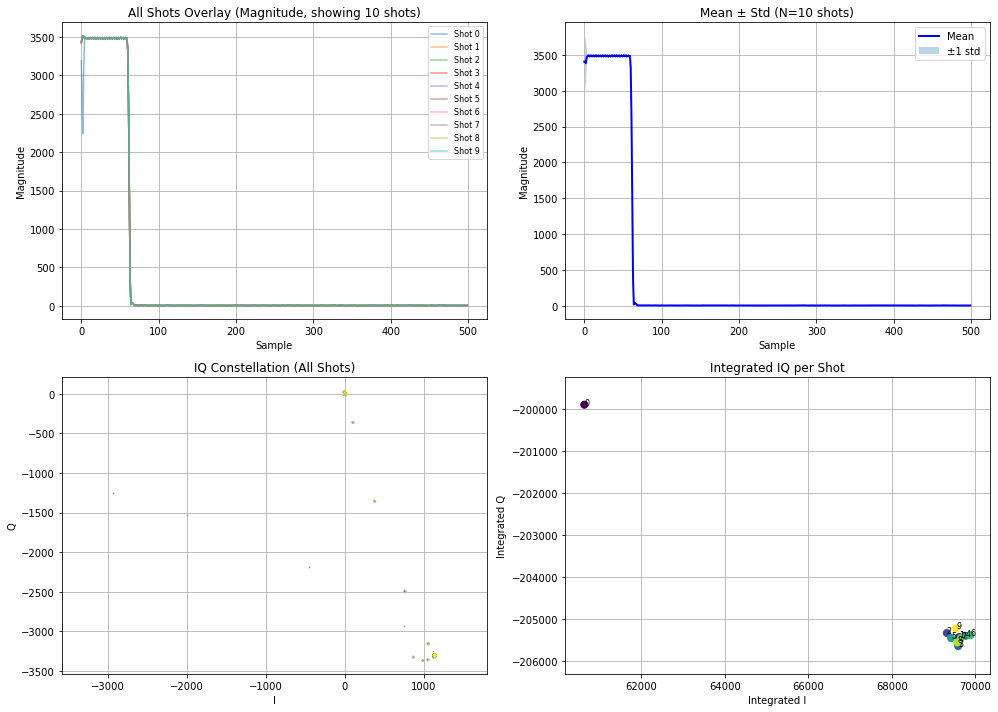

In [44]:
# Visualization of all shots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Shot overlay (magnitude)
ax = axes[0, 0]
for i in range(min(n_shots, 10)):  # Limit to 10 for clarity
    ax.plot(np.abs(data_shots[i]), alpha=0.5, label=f'Shot {i}')
ax.set_title(f'All Shots Overlay (Magnitude, showing {min(n_shots, 10)} shots)')
ax.set_xlabel('Sample')
ax.set_ylabel('Magnitude')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True)

# Mean trace with std band
ax = axes[0, 1]
mean_trace = np.abs(data_shots).mean(axis=0)
std_trace = np.abs(data_shots).std(axis=0)
ax.plot(mean_trace, 'b-', linewidth=2, label='Mean')
ax.fill_between(range(len(mean_trace)), 
                mean_trace - std_trace, 
                mean_trace + std_trace, 
                alpha=0.3, label='±1 std')
ax.set_title(f'Mean ± Std (N={n_shots} shots)')
ax.set_xlabel('Sample')
ax.set_ylabel('Magnitude')
ax.legend()
ax.grid(True)

# IQ scatter all shots
ax = axes[1, 0]
colors = plt.cm.viridis(np.linspace(0, 1, n_shots))
for i in range(n_shots):
    ax.scatter(data_shots[i].real, data_shots[i].imag, 
               s=1, alpha=0.3, c=[colors[i]])
ax.set_title('IQ Constellation (All Shots)')
ax.set_xlabel('I')
ax.set_ylabel('Q')
ax.axis('equal')
ax.grid(True)

# Integrated values per shot
ax = axes[1, 1]
int_i = [s['integrated_i'] for s in shot_stats]
int_q = [s['integrated_q'] for s in shot_stats]
ax.scatter(int_i, int_q, s=50, c=range(n_shots), cmap='viridis')
for i in range(n_shots):
    ax.annotate(str(i), (int_i[i], int_q[i]), fontsize=8)
ax.set_title('Integrated IQ per Shot')
ax.set_xlabel('Integrated I')
ax.set_ylabel('Integrated Q')
ax.axis('equal')
ax.grid(True)

plt.tight_layout()
plt.show()

## 9. Repeatability Test

Run multiple experiment iterations to check consistency.

In [45]:
print(">>> REPEATABILITY TEST (5 iterations)")

N_ITERATIONS = 5
iteration_results = []

for iteration in range(N_ITERATIONS):
    print(f"\n--- Iteration {iteration + 1}/{N_ITERATIONS} ---")
    
    t_start = time.time()
    try:
        data = backend.start_experiment(
            duration_cycles=EXPERIMENT_DURATION,
            shots=NUM_SHOTS,
            readout_cfg=readout_cfg
        )
        t_elapsed = time.time() - t_start
        
        # Compute summary stats
        mag = np.abs(data)
        iteration_results.append({
            'iteration': iteration + 1,
            'status': 'OK',
            'time_ms': t_elapsed * 1000,
            'n_samples': len(data),
            'mag_mean': mag.mean(),
            'mag_std': mag.std(),
            'integrated_i': data.real.sum(),
            'integrated_q': data.imag.sum()
        })
        
        print(f"  [OK] {len(data)} samples in {t_elapsed*1000:.1f} ms")
        
    except Exception as e:
        iteration_results.append({
            'iteration': iteration + 1,
            'status': 'FAIL',
            'error': str(e)
        })
        print(f"  [FAIL] {type(e).__name__}: {e}")

# Summary
print("\n=== REPEATABILITY SUMMARY ===")
successes = [r for r in iteration_results if r['status'] == 'OK']
print(f"Successful: {len(successes)}/{N_ITERATIONS}")

if len(successes) > 1:
    times = [r['time_ms'] for r in successes]
    mags = [r['mag_mean'] for r in successes]
    
    print(f"\nTiming consistency:")
    print(f"  Mean time: {np.mean(times):.1f} ms")
    print(f"  Std time:  {np.std(times):.1f} ms")
    
    print(f"\nSignal consistency:")
    print(f"  Mean mag_mean: {np.mean(mags):.2f}")
    print(f"  Std mag_mean:  {np.std(mags):.2f}")
    print(f"  CV: {np.std(mags)/np.mean(mags)*100:.2f}%")

[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=10
[Backend] INFO: Acquired: (5000,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=10
[Backend] INFO: Acquired: (5000,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=10
[Backend] INFO: Acquired: (5000,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=10
[Backend] INFO: Acquired: (5000,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO:

>>> REPEATABILITY TEST (5 iterations)

--- Iteration 1/5 ---
  [OK] 5000 samples in 37.4 ms

--- Iteration 2/5 ---
  [OK] 5000 samples in 37.0 ms

--- Iteration 3/5 ---
  [OK] 5000 samples in 37.4 ms

--- Iteration 4/5 ---
  [OK] 5000 samples in 37.1 ms

--- Iteration 5/5 ---
  [OK] 5000 samples in 37.8 ms

=== REPEATABILITY SUMMARY ===
Successful: 5/5

Timing consistency:
  Mean time: 37.3 ms
  Std time:  0.3 ms

Signal consistency:
  Mean mag_mean: 436.60
  Std mag_mean:  0.40
  CV: 0.09%


## 10. Stress Test: Many Rapid Acquisitions

In [46]:
print(">>> STRESS TEST: 20 rapid single-shot acquisitions")

N_RAPID = 20
rapid_results = []
t_total_start = time.time()

for i in range(N_RAPID):
    try:
        data = backend.start_experiment(
            duration_cycles=EXPERIMENT_DURATION,
            shots=1,
            readout_cfg=readout_cfg
        )
        rapid_results.append({
            'index': i,
            'status': 'OK',
            'mag_mean': np.abs(data).mean()
        })
    except Exception as e:
        rapid_results.append({
            'index': i,
            'status': 'FAIL',
            'error': str(e)
        })

t_total = time.time() - t_total_start

successes = sum(1 for r in rapid_results if r['status'] == 'OK')
print(f"\nCompleted: {successes}/{N_RAPID} successful")
print(f"Total time: {t_total:.2f} s")
print(f"Rate: {N_RAPID/t_total:.1f} experiments/sec")

if successes < N_RAPID:
    print("\nFailed acquisitions:")
    for r in rapid_results:
        if r['status'] == 'FAIL':
            print(f"  [{r['index']}] {r.get('error', 'unknown')}")

[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=1
[Backend] INFO: Acquired: (500,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=1
[Backend] INFO: Acquired: (500,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=1
[Backend] INFO: Acquired: (500,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=1
[Backend] INFO: Acquired: (500,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 

>>> STRESS TEST: 20 rapid single-shot acquisitions


[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=1
[Backend] INFO: Acquired: (500,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=1
[Backend] INFO: Acquired: (500,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=1
[Backend] INFO: Acquired: (500,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=1
[Backend] INFO: Acquired: (500,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=100, tof=80, acq=1000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Du


Completed: 20/20 successful
Total time: 0.76 s
Rate: 26.4 experiments/sec


## 11. Final Health Check & Summary

In [48]:
print("\n" + "="*60)
print("EXPERIMENT COMPLETE")
print("="*60)

# Final health check
print("\nFinal Hardware State:")
final_health = backend.check_hardware_health()
print_health(final_health)

# Summary of all tests
print("\n" + "="*60)
print("TEST SUMMARY")
print("="*60)

print(f"\n1. Single Shot Test: OK")
print(f"   - Samples: {len(data_single)}")

print(f"\n2. Multi-Shot Test ({NUM_SHOTS} shots): OK")
print(f"   - Total samples: {len(data_multi)}")
print(f"   - Shots extracted: {data_shots.shape[0]}")

print(f"\n3. Repeatability Test ({N_ITERATIONS} iterations):")
print(f"   - Success rate: {successes}/{N_ITERATIONS}")

print(f"\n4. Stress Test ({N_RAPID} rapid acquisitions):")
stress_success = sum(1 for r in rapid_results if r['status'] == 'OK')
print(f"   - Success rate: {stress_success}/{N_RAPID}")
print(f"   - Throughput: {N_RAPID/t_total:.1f} exp/sec")

print("\n" + "="*60)
if final_health['dma'] == 'idle' and stress_success == N_RAPID:
    print(" ALL TESTS PASSED ")
else:
    print("SOME ISSUES DETECTED - Review logs above")
print("="*60)


EXPERIMENT COMPLETE

Final Hardware State:

=== HARDWARE HEALTH ===
  DMA:     idle
  Clocks:  ok
  Trigger: done
  Gen[0]: ok
  Acq[0]: ok
  Acq[1]: ok

 All systems nominal

TEST SUMMARY

1. Single Shot Test: OK
   - Samples: 500

2. Multi-Shot Test (10 shots): OK
   - Total samples: 5000
   - Shots extracted: 10

3. Repeatability Test (5 iterations):
   - Success rate: 20/5

4. Stress Test (20 rapid acquisitions):
   - Success rate: 20/20
   - Throughput: 26.4 exp/sec

 ALL TESTS PASSED 
